# CIFAR100 ResNet34 AdamW: Metrics and Plots

Notebook builds plots in the style of `aboba-vits.ipynb`, but loads data directly from local `mlruns` files.


In [1]:
from pathlib import Path
import re

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle


In [2]:
MLRUNS_ROOT = Path('~/Downloads/mlruns-cifar100').expanduser()
METRICS_CSV = Path('cifar100_metrics_long.csv')

MODEL_FILTER = 'resnet34'
DATASET_PREFIX = 'adamw-cifar100-'
ABOBA_BASELINE_ABM = '4'
ABOBA_ABMS = ['2', '4', '8', '16']  # None -> all found in data

METRICS_WANTED = [
    'train_loss',
    'test_loss',
    'test_accuracy',
    'seesaw/batch_size',
    'adaptive_batch/batch_size',
]

REBUILD_CACHE = True


In [3]:
def _read_meta_name(meta_path: Path) -> str | None:
    if not meta_path.exists():
        return None
    for line in meta_path.read_text(encoding='utf-8').splitlines():
        if line.startswith('name: '):
            return line[len('name: '):].strip()
    return None


def _read_param(path: Path) -> str | None:
    if not path.exists():
        return None
    value = path.read_text(encoding='utf-8').strip()
    return value if value else None


def _normalize_abm(abm_raw: str | None) -> str:
    if not abm_raw:
        return ''
    abm = abm_raw.strip()
    if abm.endswith('.0'):
        abm = abm[:-2]
    return abm


def parse_experiment_name(name: str) -> dict | None:
    pattern = rf'^{re.escape(DATASET_PREFIX)}(basic|seesaw|aboba)-bs(\d+)-seed(\d+)(?:-abm([\d\.]+))?$'
    match = re.match(pattern, name)
    if not match:
        return None

    variant, bs, seed, abm_raw = match.groups()
    return {
        'variant': variant,
        'batch_size': int(bs),
        'seed': f'seed{int(seed)}',
        'abm': _normalize_abm(abm_raw),
    }


def normalize_run_label(variant: str, batch_size: int, abm: str) -> str:
    if variant == 'basic':
        return f'sgd {batch_size}'
    if variant == 'seesaw':
        return f'sgd_seesaw {batch_size}'
    if variant == 'aboba':
        return f'sgboba {batch_size} abm{abm}' if abm else f'sgboba {batch_size}'
    return f'{variant} {batch_size}'


def _iter_metric_points(metric_path: Path):
    # MLflow metric line format: <timestamp> <value> <step>
    for line in metric_path.read_text(encoding='utf-8').splitlines():
        parts = line.strip().split()
        if len(parts) < 3:
            continue
        value = float(parts[1])
        step = int(float(parts[2]))
        yield step, value


def load_metrics_long_from_mlruns(mlruns_root: Path, model_filter: str = 'resnet34'):
    rows = []
    stats = {
        'experiments_total': 0,
        'experiments_matched': 0,
        'runs_total': 0,
        'runs_model_ok': 0,
        'runs_skipped_model': 0,
    }

    exp_dirs = sorted([p for p in mlruns_root.iterdir() if p.is_dir() and p.name.isdigit()])

    for exp_dir in exp_dirs:
        stats['experiments_total'] += 1
        exp_name = _read_meta_name(exp_dir / 'meta.yaml')
        if not exp_name:
            continue

        parsed = parse_experiment_name(exp_name)
        if not parsed:
            continue

        stats['experiments_matched'] += 1

        run_dirs = [p for p in exp_dir.iterdir() if p.is_dir() and len(p.name) == 32]
        for run_dir in run_dirs:
            stats['runs_total'] += 1
            model = _read_param(run_dir / 'params' / 'model')
            if model_filter and model != model_filter:
                stats['runs_skipped_model'] += 1
                continue

            stats['runs_model_ok'] += 1

            run_label = normalize_run_label(parsed['variant'], parsed['batch_size'], parsed['abm'])
            metrics_dir = run_dir / 'metrics'

            for metric in METRICS_WANTED:
                metric_path = metrics_dir / metric
                if not metric_path.exists():
                    continue
                for step, value in _iter_metric_points(metric_path):
                    rows.append({
                        'run': run_label,
                        'variant': parsed['variant'],
                        'batch_size': parsed['batch_size'],
                        'seed': parsed['seed'],
                        'abm': parsed['abm'],
                        'metric': metric,
                        'step': step,
                        'value': value,
                    })

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(['metric', 'run', 'seed', 'step']).reset_index(drop=True)

    return df, stats


In [4]:
if REBUILD_CACHE or (not METRICS_CSV.exists()):
    df, load_stats = load_metrics_long_from_mlruns(MLRUNS_ROOT, model_filter=MODEL_FILTER)
    df.to_csv(METRICS_CSV, index=False)
else:
    df = pd.read_csv(METRICS_CSV)
    load_stats = None

print(f'Rows: {len(df)}')
print(f'CSV: {METRICS_CSV.resolve()}')
if load_stats is not None:
    print('Load stats:', load_stats)


Rows: 2736
CSV: /Users/alex/laba/ALSO/paper/Adaptive Batching on ViTs/notebooks/cifar100_metrics_long.csv
Load stats: {'experiments_total': 30, 'experiments_matched': 18, 'runs_total': 18, 'runs_model_ok': 18, 'runs_skipped_model': 0}


In [5]:
if df.empty:
    raise RuntimeError('No data loaded. Check MLRUNS_ROOT and filters.')

print('Unique variants:', sorted(df['variant'].unique().tolist()))
print('Unique abm:', sorted([x for x in df['abm'].dropna().astype(str).unique().tolist() if x]))
print('Unique seeds:', sorted(df['seed'].unique().tolist()))
print('Unique metrics:', sorted(df['metric'].unique().tolist()))

step_ranges = df.groupby('metric')['step'].agg(['min', 'max']).sort_index()
print('\nStep ranges by metric:')
print(step_ranges)


Unique variants: ['aboba', 'basic', 'seesaw']
Unique abm: ['16', '2', '4', '8']
Unique seeds: ['seed1', 'seed2', 'seed3']
Unique metrics: ['adaptive_batch/batch_size', 'seesaw/batch_size', 'test_accuracy', 'test_loss', 'train_loss']

Step ranges by metric:
                           min  max
metric                             
adaptive_batch/batch_size    2   39
seesaw/batch_size            0   39
test_accuracy                0   39
test_loss                    0   39
train_loss                   0   39


In [6]:
coverage = (
    df[['variant', 'abm', 'seed']]
    .drop_duplicates()
    .groupby(['variant', 'abm'])['seed']
    .nunique()
    .reset_index(name='seed_count')
    .sort_values(['variant', 'abm'])
)
print(coverage)

basic_ok = coverage[(coverage['variant'] == 'basic') & (coverage['abm'] == '')]['seed_count'].eq(3).all()
seesaw_ok = coverage[(coverage['variant'] == 'seesaw') & (coverage['abm'] == '')]['seed_count'].eq(3).all()
aboba_cov = coverage[coverage['variant'] == 'aboba'].copy()
expected_abm = ABOBA_ABMS if ABOBA_ABMS is not None else sorted(aboba_cov['abm'].tolist())
aboba_ok = set(expected_abm).issubset(set(aboba_cov['abm'].tolist())) and aboba_cov['seed_count'].eq(3).all()

print('\nChecks:')
print('basic has 3 seeds:', basic_ok)
print('seesaw has 3 seeds:', seesaw_ok)
print('aboba expected abm with 3 seeds:', aboba_ok)


  variant abm  seed_count
0   aboba  16           3
1   aboba   2           3
2   aboba   4           3
3   aboba   8           3
4   basic               3
5  seesaw               3

Checks:
basic has 3 seeds: True
seesaw has 3 seeds: True
aboba expected abm with 3 seeds: True


In [7]:
sns.set_theme(style='whitegrid', context='talk')

BATCH_SIZE = int(df['batch_size'].mode().iloc[0])

BASELINE_RUNS = [
    f'sgd {BATCH_SIZE}',
    f'sgd_seesaw {BATCH_SIZE}',
    f'sgboba {BATCH_SIZE} abm{ABOBA_BASELINE_ABM}',
]

ABOBA_RUNS_ALL = [f'sgboba {BATCH_SIZE} abm{a}' for a in (ABOBA_ABMS if ABOBA_ABMS is not None else sorted(df[df['variant'] == 'aboba']['abm'].unique().tolist()))]
ALL_MAIN_RUNS = [f'sgd {BATCH_SIZE}', f'sgd_seesaw {BATCH_SIZE}', *ABOBA_RUNS_ALL]

PALETTE = {
    f'sgd {BATCH_SIZE}': '#00f496',
    f'sgd_seesaw {BATCH_SIZE}': '#0a710a',
    f'sgboba {BATCH_SIZE} abm2': '#8dd3c7',
    f'sgboba {BATCH_SIZE} abm4': '#e03f92',
    f'sgboba {BATCH_SIZE} abm8': '#0099ff',
    f'sgboba {BATCH_SIZE} abm16': '#d95f02',
}


def _existing_runs(order):
    present = set(df['run'].unique().tolist())
    return [r for r in order if r in present]


def plot_metric(metric, runs, title, yscale=None, legend_loc='best', ylim=None):
    run_order = _existing_runs(runs)
    plot_df = df[(df['metric'] == metric) & (df['run'].isin(run_order))]

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(
        data=plot_df,
        x='step',
        y='value',
        hue='run',
        hue_order=run_order,
        palette={k: PALETTE[k] for k in run_order},
        estimator='mean',
        errorbar='sd',
        lw=2.5,
        alpha=0.9,
        ax=ax,
    )

    ax.set(title=title, xlabel='Step', ylabel=metric)
    if yscale:
        ax.set_yscale(yscale)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(title='Run', loc=legend_loc)
    plt.tight_layout()
    plt.show()


def plot_accuracy_with_inset(runs, title, legend_loc='lower right', inset_anchor=(0.2, 0.05, 1, 1), window=6):
    run_order = _existing_runs(runs)
    plot_df = df[(df['metric'] == 'test_accuracy') & (df['run'].isin(run_order))]

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(
        data=plot_df,
        x='step',
        y='value',
        hue='run',
        hue_order=run_order,
        palette={k: PALETTE[k] for k in run_order},
        estimator='mean',
        errorbar='sd',
        lw=2.5,
        alpha=0.9,
        ax=ax,
    )
    ax.set(title=title, xlabel='Step', ylabel='Accuracy')
    ax.legend(title='Run', loc=legend_loc)

    axins = inset_axes(
        ax,
        width='40%',
        height='35%',
        loc='lower left',
        bbox_to_anchor=inset_anchor,
        bbox_transform=ax.transAxes,
        borderpad=0.8,
    )
    sns.lineplot(
        data=plot_df,
        x='step',
        y='value',
        hue='run',
        hue_order=run_order,
        palette={k: PALETTE[k] for k in run_order},
        estimator='mean',
        errorbar='sd',
        lw=2.0,
        alpha=0.95,
        legend=False,
        ax=axins,
    )

    x1 = float(plot_df['step'].max())
    x0 = x1 - window
    mean_df = plot_df.groupby(['run', 'step'])['value'].mean().reset_index()
    zoom_df = mean_df[mean_df['step'].between(x0, x1)]

    y0 = float(zoom_df['value'].min())
    y1 = float(zoom_df['value'].max())
    pad = max(0.002, 0.05 * (y1 - y0))

    axins.set_xlim(x0, x1)
    axins.set_ylim(y0 - pad, y1 + pad)
    axins.set_title('last steps', fontsize=10)
    axins.tick_params(axis='both', labelsize=8)

    rect = Rectangle((x0, y0 - pad), x1 - x0, (y1 - y0) + 2 * pad, fill=False, ec='black', lw=1.1, alpha=0.8)
    ax.add_patch(rect)

    plt.tight_layout()
    plt.show()


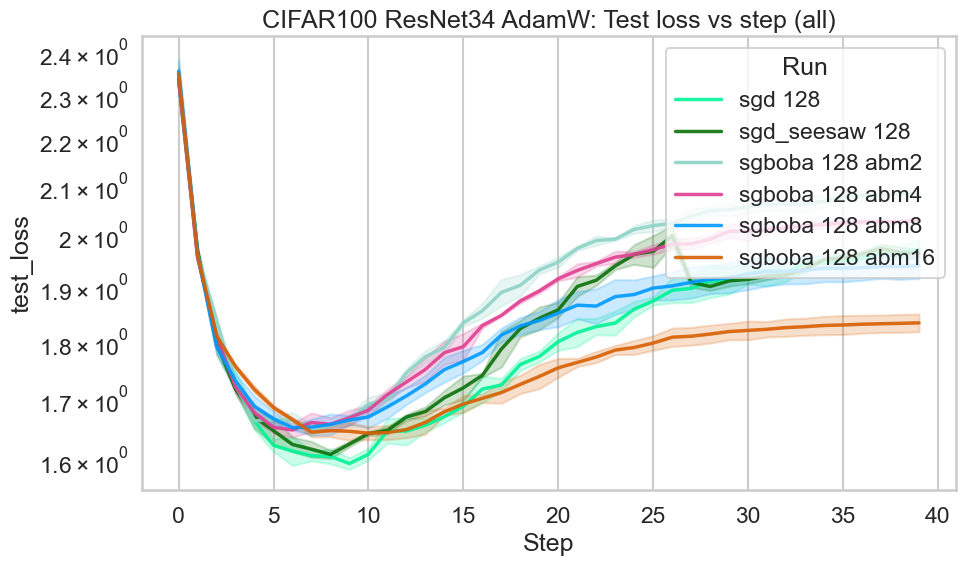

In [8]:
plot_metric(
    metric='test_loss',
    runs=ALL_MAIN_RUNS,
    title='CIFAR100 ResNet34 AdamW: Test loss vs step (all)',
    yscale='log',
    legend_loc='upper right',
)


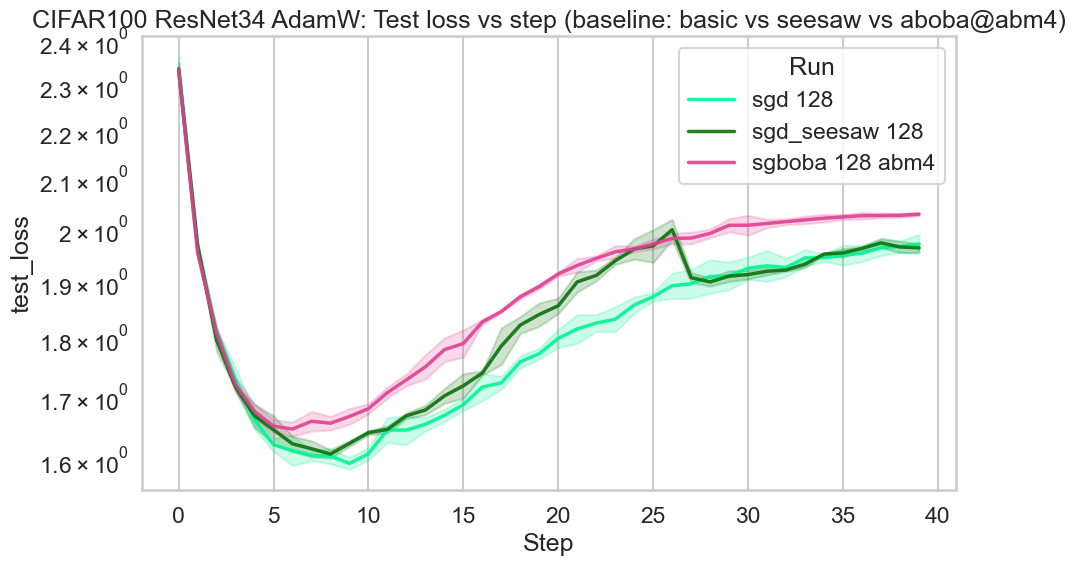

In [9]:
plot_metric(
    metric='test_loss',
    runs=BASELINE_RUNS,
    title='CIFAR100 ResNet34 AdamW: Test loss vs step (baseline: basic vs seesaw vs aboba@abm4)',
    yscale='log',
    legend_loc='upper right',
)


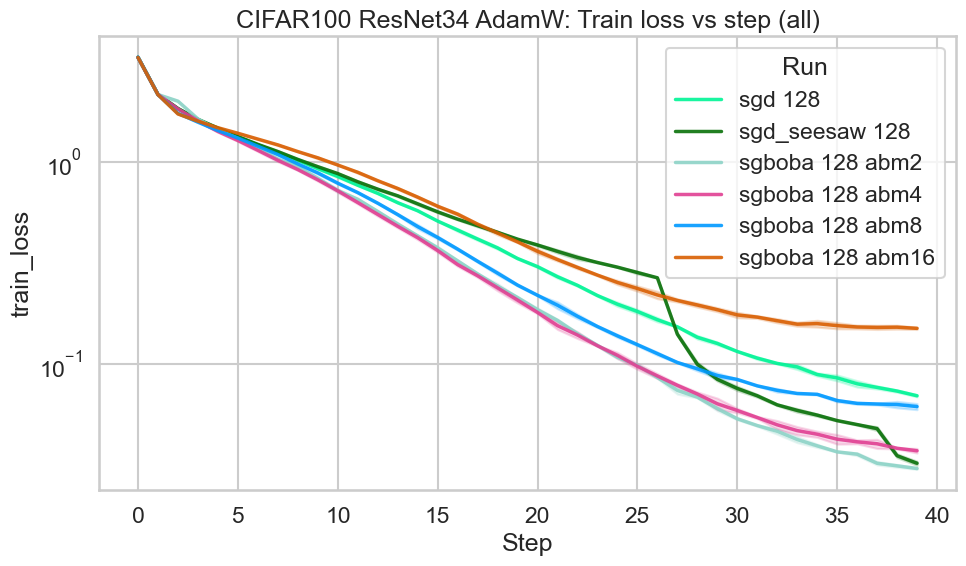

In [10]:
plot_metric(
    metric='train_loss',
    runs=ALL_MAIN_RUNS,
    title='CIFAR100 ResNet34 AdamW: Train loss vs step (all)',
    yscale='log',
    legend_loc='upper right',
)


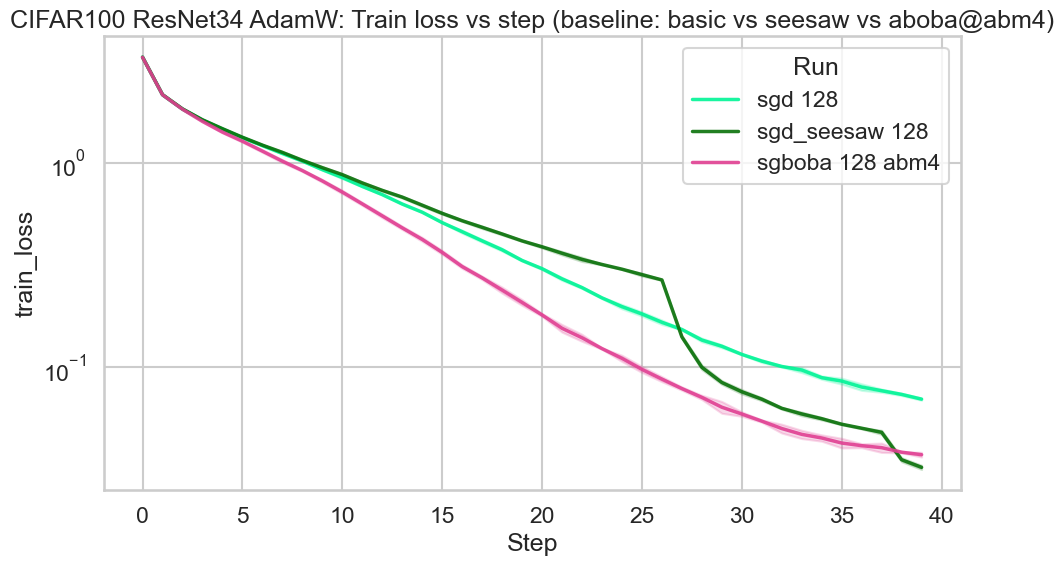

In [11]:
plot_metric(
    metric='train_loss',
    runs=BASELINE_RUNS,
    title='CIFAR100 ResNet34 AdamW: Train loss vs step (baseline: basic vs seesaw vs aboba@abm4)',
    yscale='log',
    legend_loc='upper right',
)


/var/folders/fw/_g62j85x4r934wtl7_x64hcc0000gn/T/ipykernel_91733/3461681632.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


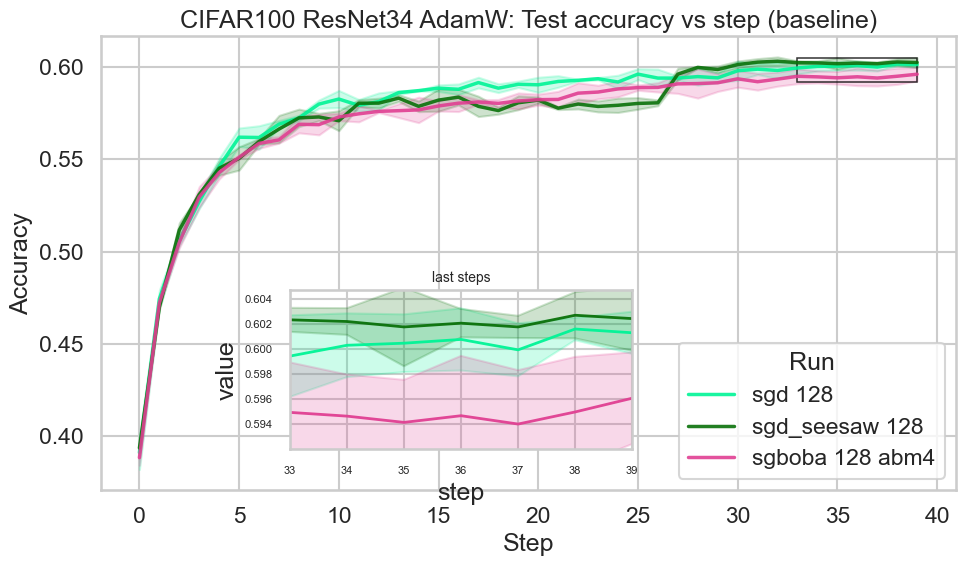

In [12]:
plot_accuracy_with_inset(
    runs=BASELINE_RUNS,
    title='CIFAR100 ResNet34 AdamW: Test accuracy vs step (baseline)',
    legend_loc='lower right',
    inset_anchor=(0.2, 0.05, 1, 1),
    window=6,
)


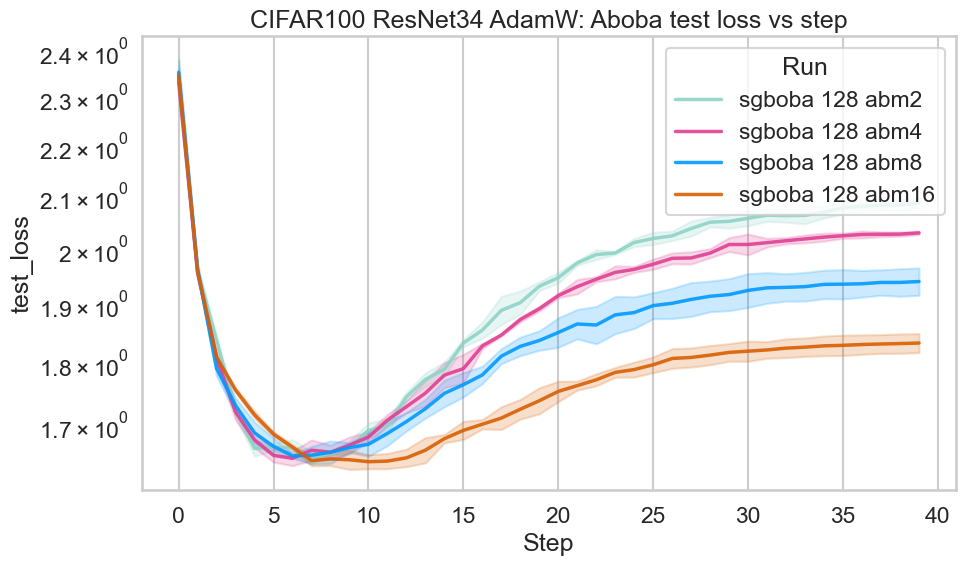

In [13]:
plot_metric(
    metric='test_loss',
    runs=ABOBA_RUNS_ALL,
    title='CIFAR100 ResNet34 AdamW: Aboba test loss vs step',
    yscale='log',
    legend_loc='upper right',
)


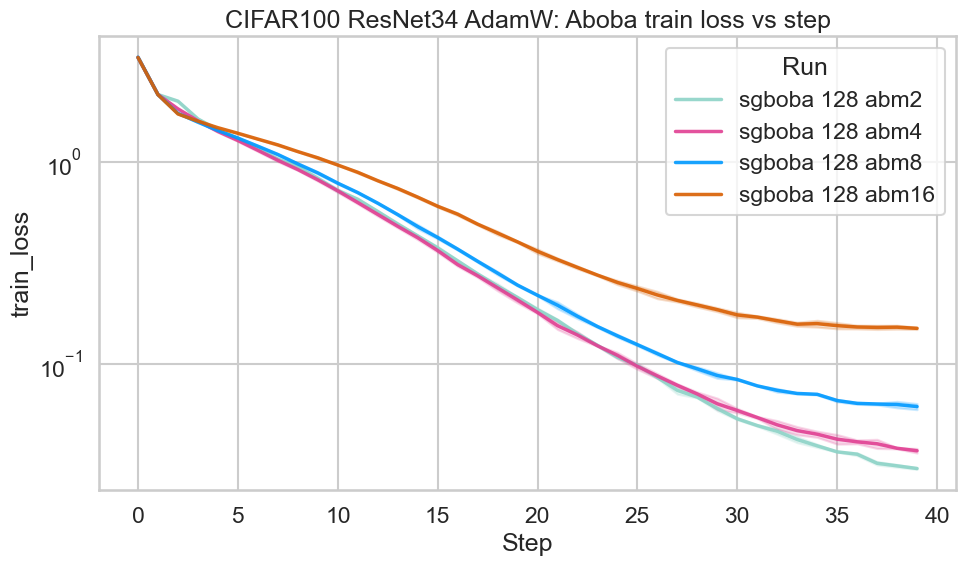

In [14]:
plot_metric(
    metric='train_loss',
    runs=ABOBA_RUNS_ALL,
    title='CIFAR100 ResNet34 AdamW: Aboba train loss vs step',
    yscale='log',
    legend_loc='upper right',
)


/var/folders/fw/_g62j85x4r934wtl7_x64hcc0000gn/T/ipykernel_91733/3461681632.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


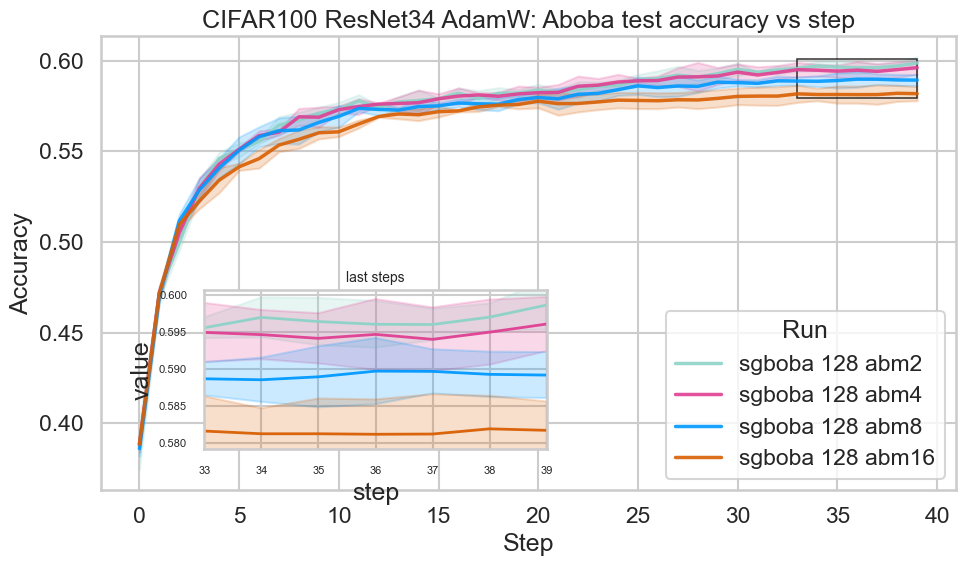

In [15]:
plot_accuracy_with_inset(
    runs=ABOBA_RUNS_ALL,
    title='CIFAR100 ResNet34 AdamW: Aboba test accuracy vs step',
    legend_loc='lower right',
    inset_anchor=(0.1, 0.05, 1, 1),
    window=6,
)


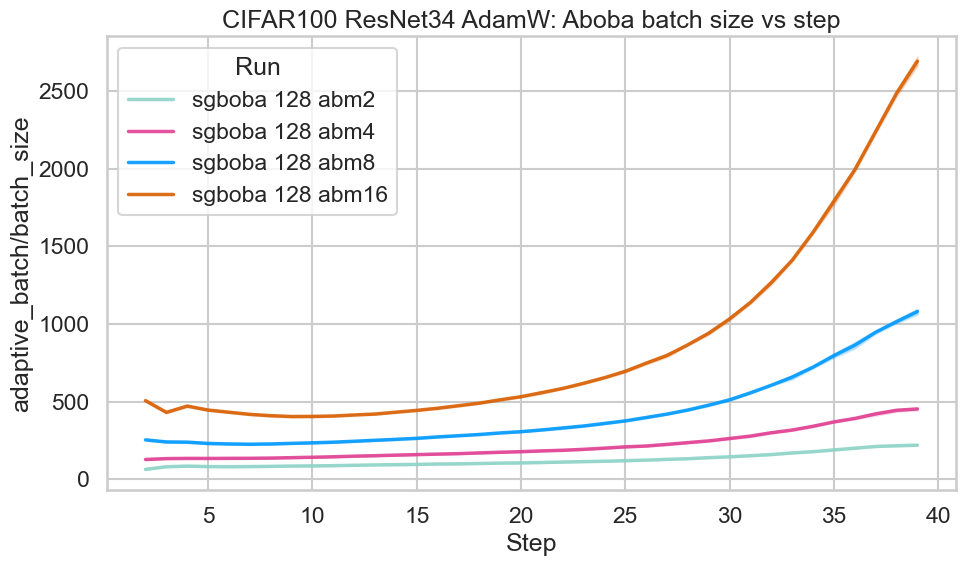

In [16]:
plot_metric(
    metric='adaptive_batch/batch_size',
    runs=ABOBA_RUNS_ALL,
    title='CIFAR100 ResNet34 AdamW: Aboba batch size vs step',
    legend_loc='upper left',
)


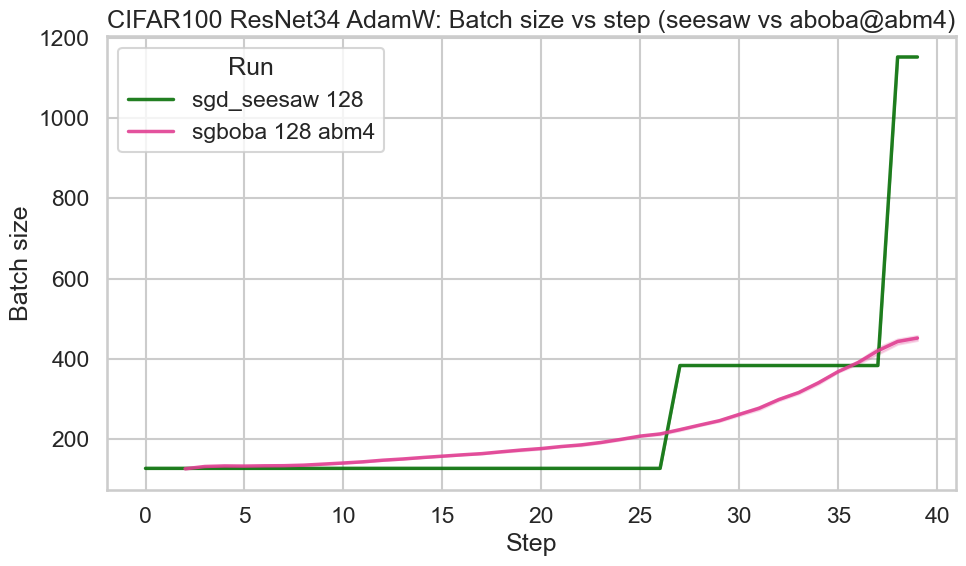

In [17]:
batch_runs = [f'sgd_seesaw {BATCH_SIZE}', f'sgboba {BATCH_SIZE} abm{ABOBA_BASELINE_ABM}']
plot_df = df[
    (df['metric'].isin(['adaptive_batch/batch_size', 'seesaw/batch_size']))
    & (df['run'].isin(_existing_runs(batch_runs)))
]

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=plot_df,
    x='step',
    y='value',
    hue='run',
    hue_order=_existing_runs(batch_runs),
    palette={k: PALETTE[k] for k in _existing_runs(batch_runs)},
    estimator='mean',
    errorbar='sd',
    lw=2.5,
    alpha=0.9,
    ax=ax,
)

ax.set(
    title='CIFAR100 ResNet34 AdamW: Batch size vs step (seesaw vs aboba@abm4)',
    xlabel='Step',
    ylabel='Batch size',
)
ax.legend(title='Run', loc='upper left')
plt.tight_layout()
plt.show()
